In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📌 Extracão

In [ ]:
dados = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json')

In [ ]:
df_normal_c = pd.json_normalize(dados['customer'])
df_normal_p = pd.json_normalize(dados['phone'])
df_normal_i = pd.json_normalize(dados['internet'])
df_normal_a = pd.json_normalize(dados['account'])

In [ ]:
df_completo = pd.concat(
    [
        dados[['customerID', 'Churn']],
        df_normal_c,
        df_normal_p,
        df_normal_i,
        df_normal_a
    ],
    axis=1
)

In [ ]:
df_completo.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [ ]:
df_completo.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [ ]:
df_completo["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [ ]:
(df_completo["Churn"] == "").sum()

np.int64(224)

In [ ]:
df_completo = df_completo[df_completo["Churn"] != ""]

In [ ]:
df_completo["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [ ]:
df_completo["Charges.Total"] = pd.to_numeric(
    df_completo["Charges.Total"],
    errors="coerce"
)

In [ ]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [ ]:
df_completo.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [ ]:
df_completo = df_completo.dropna()

In [ ]:
df_completo.duplicated().sum()

np.int64(0)

In [ ]:
df_completo.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_completo.to_csv('/content/drive/MyDrive/telecomx_tratado.csv', index=False)

#📊 Carga e análise

In [ ]:
df_completo.describe(include='all')

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
count,7032,7032,7032,7032.000000,7032,7032,7032.000000,7032,7032,7032,...,7032,7032,7032,7032,7032,7032,7032,7032,7032.000000,7032.000000
unique,7032,2,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,NaN
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN
freq,1,5163,3549,NaN,3639,4933,NaN,6352,3385,3096,...,3087,3094,3472,2809,2781,3875,4168,2365,NaN,NaN
mean,NaN,NaN,NaN,0.162400,NaN,NaN,32.421786,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.798208,2283.300441
std,NaN,NaN,NaN,0.368844,NaN,NaN,24.545260,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.085974,2266.771362
min,NaN,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.587500,401.450000
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.862500,3794.737500


In [ ]:
df_completo.describe(include="object")

,customerID,Churn,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,5163,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365


In [ ]:
df_completo.describe()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


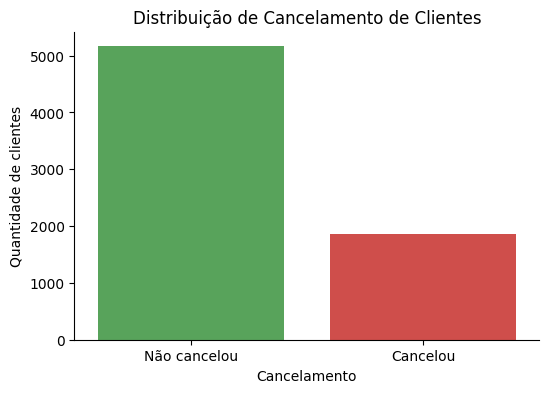

In [ ]:
grafico_churn_geral = plt.figure(figsize=(6,4))

sns.countplot(
    data=df_completo,
    x='Churn',
    hue='Churn',
    palette=['#4CAF50','#E53935'],
    legend=False
)

plt.title('Distribuição de Cancelamento de Clientes')
plt.xlabel('Cancelamento')
plt.ylabel('Quantidade de clientes')

plt.xticks(
    ticks=[0,1],
    labels=['Não cancelou','Cancelou']
)

sns.despine()

plt.show()

In [ ]:
taxa_churn = (
    df_completo
    .groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .rename('proporcao')
    .reset_index()
)

taxa_churn = taxa_churn[taxa_churn['Churn'] == 'Yes']

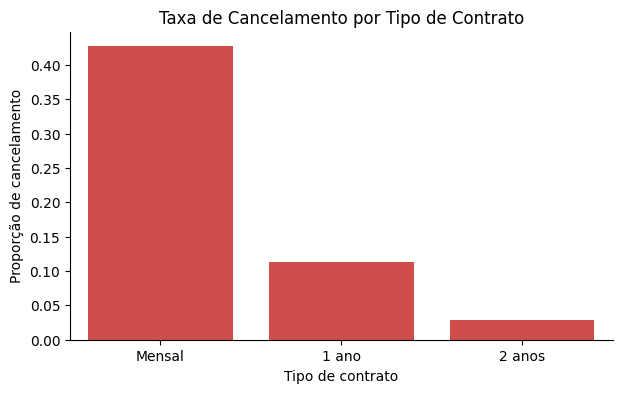

In [ ]:
grafico_churn_contrato=plt.figure(figsize=(7,4))

sns.barplot(
    data=taxa_churn,
    x='Contract',
    y='proporcao',
    color='#E53935'
)

plt.title('Taxa de Cancelamento por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Proporção de cancelamento')

plt.xticks(
    ticks=[0,1,2],
    labels=['Mensal','1 ano','2 anos']
)

sns.despine()

plt.show()

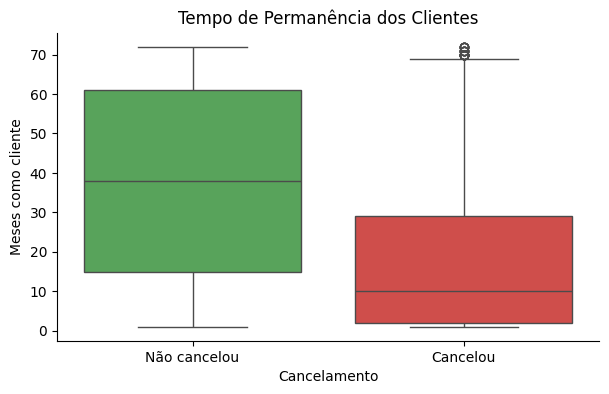

In [ ]:
grafico_tenure=plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_completo,
    x='Churn',
    y='tenure',
    hue='Churn',
    palette=['#4CAF50','#E53935'],
    legend=False
)

plt.title('Tempo de Permanência dos Clientes')
plt.xlabel('Cancelamento')
plt.ylabel('Meses como cliente')

plt.xticks(
    ticks=[0,1],
    labels=['Não cancelou','Cancelou']
)

sns.despine()

plt.show()

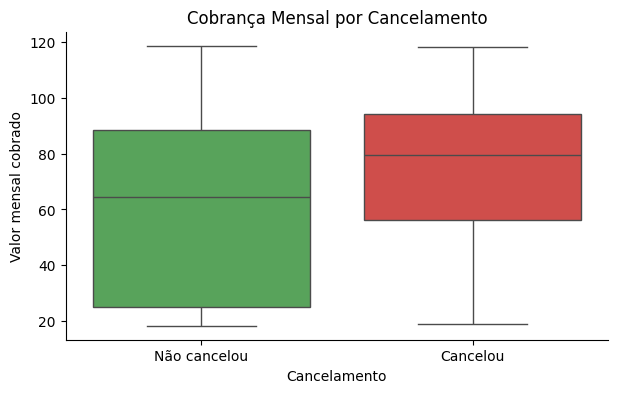

In [ ]:
grafico_cobranca=plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_completo,
    x='Churn',
    y='Charges.Monthly',
    hue='Churn',
    palette=['#4CAF50','#E53935'],
    legend=False
)

plt.title('Cobrança Mensal por Cancelamento')
plt.xlabel('Cancelamento')
plt.ylabel('Valor mensal cobrado')

plt.xticks(
    ticks=[0,1],
    labels=['Não cancelou','Cancelou']
)

sns.despine()

plt.show()

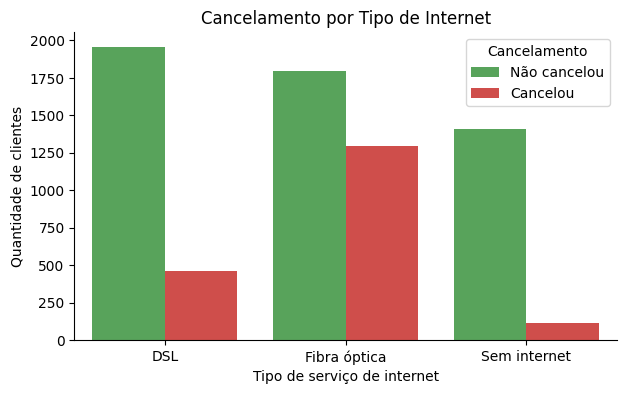

In [ ]:
grafico_internet=plt.figure(figsize=(7,4))

sns.countplot(
    data=df_completo,
    x='InternetService',
    hue='Churn',
    palette=['#4CAF50','#E53935']
)

plt.title('Cancelamento por Tipo de Internet')
plt.xlabel('Tipo de serviço de internet')
plt.ylabel('Quantidade de clientes')

plt.xticks(
    ticks=[0,1,2],
    labels=['DSL','Fibra óptica','Sem internet']
)

plt.legend(title='Cancelamento', labels=['Não cancelou','Cancelou'])

sns.despine()

plt.show()

In [ ]:
df_completo['PaymentMethod'] = df_completo['PaymentMethod'].replace({
    'Electronic check': 'Cheque eletrônico',
    'Mailed check': 'Cheque enviado',
    'Bank transfer (automatic)': 'Transferência bancária automática',
    'Credit card (automatic)': 'Cartão de crédito automático'
})

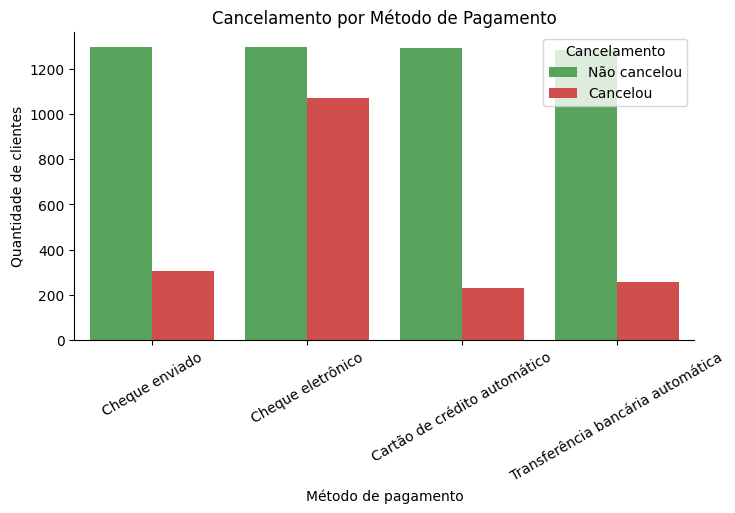

In [ ]:
grafico_churn_pagamento=plt.figure(figsize=(8,4))

sns.countplot(
    data=df_completo,
    x='PaymentMethod',
    hue='Churn',
    palette=['#4CAF50','#E53935']
)

plt.title('Cancelamento por Método de Pagamento')
plt.xlabel('Método de pagamento')
plt.ylabel('Quantidade de clientes')

plt.xticks(rotation=30)

plt.legend(title='Cancelamento', labels=['Não cancelou','Cancelou'])

sns.despine()

plt.show()

In [ ]:
categorical_cols = df_completo.select_dtypes(include='object').columns

for col in categorical_cols:
    if col not in ['customerID', 'Churn']:
        print(f'\nDistribuição de Churn por {col}')
        print(pd.crosstab(df_completo[col], df_completo['Churn'], normalize='index') * 100)


Distribuição de Churn por gender
Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565

Distribuição de Churn por Partner
Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065

Distribuição de Churn por Dependents
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205

Distribuição de Churn por PhoneService
Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.252519  26.747481

Distribuição de Churn por MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.000000  25.000000
Yes               71.351534  28.648466

Distribuição de Churn por InternetService
Churn                   No        Yes
InternetService             

In [ ]:
df_completo.groupby('Churn')[['tenure','Charges.Monthly','Charges.Total']].mean()

,tenure,Charges.Monthly,Charges.Total
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


#📄Relatorio Final

1. Introdução

A evasão de clientes, também conhecida como Churn, representa o cancelamento de serviços por parte dos clientes de uma empresa. Em empresas de telecomunicações, compreender os fatores que levam os clientes a cancelar seus contratos é fundamental para desenvolver estratégias de retenção e melhorar a satisfação do consumidor.

O objetivo desta análise é explorar os dados de clientes de uma empresa de telecomunicações para identificar padrões relacionados à evasão. A partir dessa análise, buscamos compreender quais características estão mais associadas ao cancelamento do serviço e gerar insights que possam auxiliar na redução do churn.

2. Limpeza e Tratamento de Dados

O primeiro passo do projeto foi a importação e preparação dos dados para análise.

Inicialmente, os dados foram carregados para um DataFrame utilizando a biblioteca Pandas. Em seguida, foram realizadas etapas de inspeção para compreender a estrutura do conjunto de dados, como verificação dos tipos de variáveis, presença de valores ausentes e consistência das informações.

Durante o processo de tratamento, foram realizadas as seguintes etapas:

Conversão de tipos de dados quando necessário.

Verificação e tratamento de valores nulos ou inconsistentes.

Organização das colunas para facilitar a análise.

Preparação das variáveis relacionadas ao churn para permitir comparações entre clientes que cancelaram e os que permaneceram.

Essas etapas garantiram que o conjunto de dados estivesse limpo, consistente e pronto para a análise exploratória.

3. Análise Exploratória de Dados

Após o tratamento dos dados, foi realizada uma análise exploratória com o objetivo de identificar padrões e possíveis fatores associados à evasão de clientes.

Foram criadas visualizações utilizando as bibliotecas Matplotlib e Seaborn, permitindo observar a distribuição do churn em relação a diferentes variáveis.

Entre as análises realizadas, destacam-se:

Distribuição geral de clientes que cancelaram e que permaneceram.

Comparação da evasão por tipo de contrato.

Comparação da evasão por método de pagamento.

Análise da evasão em relação ao tempo de permanência do cliente (tenure).

Relação entre valor da cobrança mensal e cancelamento do serviço.

relação entre serviço de internet e cancelamento.

Os gráficos permitiram identificar padrões importantes no comportamento dos clientes e auxiliaram na compreensão de quais perfis apresentam maior probabilidade de cancelamento.

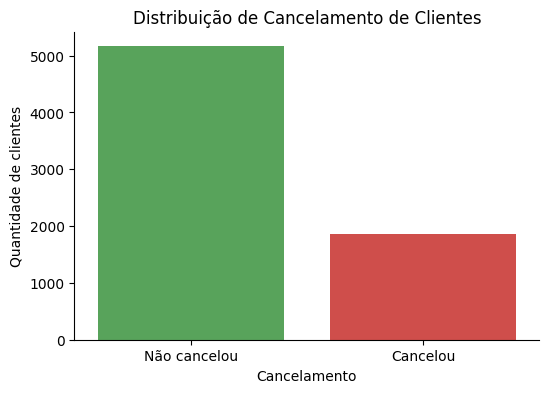

In [ ]:
grafico_churn_geral

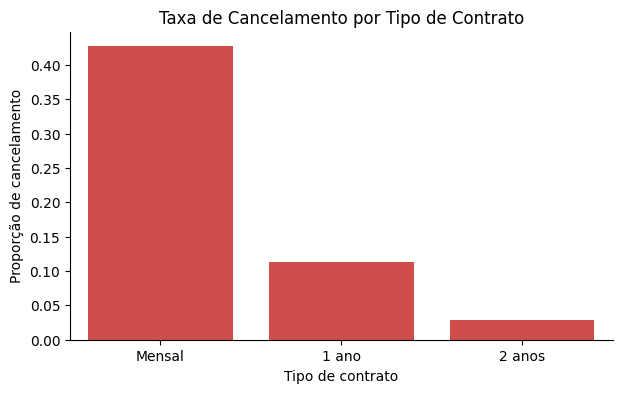

In [ ]:
grafico_churn_contrato

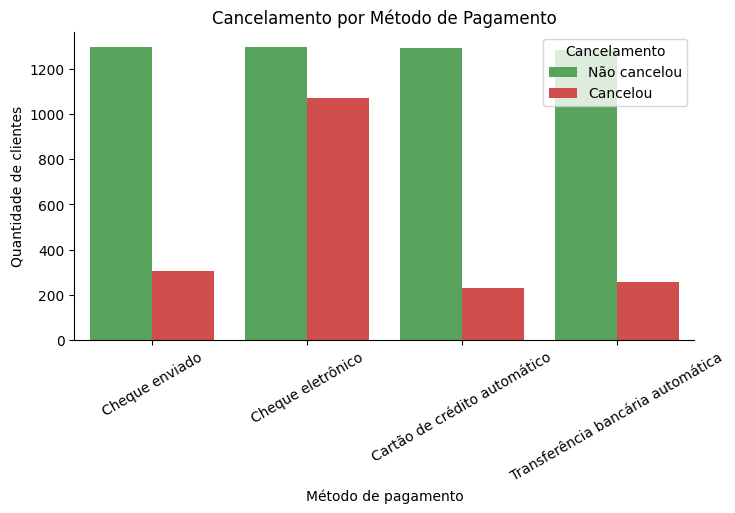

In [ ]:
grafico_churn_pagamento

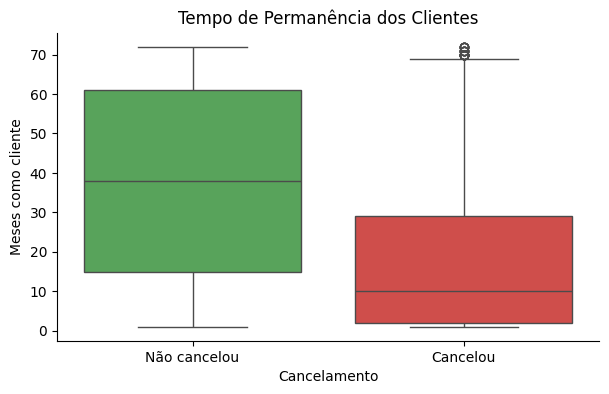

In [ ]:
grafico_tenure

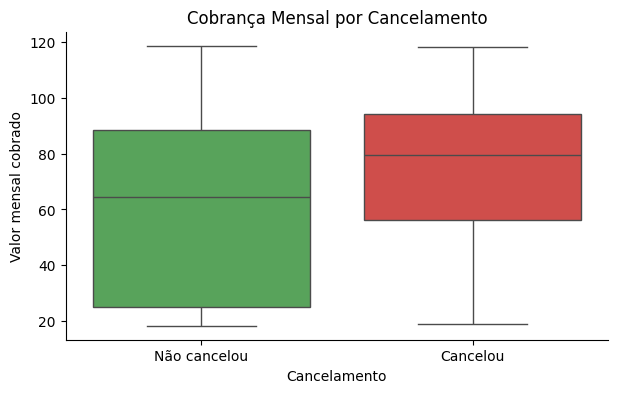

In [ ]:
grafico_cobranca

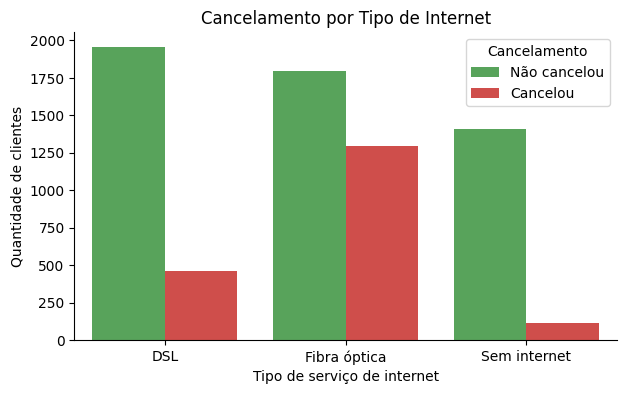

In [ ]:
grafico_internet

4. Conclusões e Insights

A análise exploratória permitiu identificar alguns padrões importantes relacionados à evasão de clientes:

Clientes com contratos mensais apresentam maior probabilidade de cancelamento.

Clientes com contratos de longo prazo tendem a permanecer mais tempo na empresa.

O método de pagamento automático está associado a menor taxa de churn.

Clientes com menor tempo de permanência na empresa apresentam maior risco de cancelamento.

Valores mais altos de cobrança mensal podem influenciar a decisão de cancelamento.

Clientes que utilizam internet de fibra óptica apresentam taxas mais elevadas de churn, indicando um possível ponto de atenção para a empresa.

Esses padrões ajudam a compreender melhor o comportamento dos clientes e os fatores que podem influenciar a decisão de cancelar o serviço.

5. Recomendações

Com base nos insights obtidos na análise, algumas estratégias podem ser sugeridas para reduzir a evasão de clientes:

Incentivar a adesão a contratos de longo prazo, oferecendo benefícios ou descontos para clientes que optarem por planos anuais.

Estimular o uso de pagamento automático, facilitando o processo de pagamento e reduzindo possíveis cancelamentos.

Desenvolver estratégias de retenção para novos clientes, já que clientes com pouco tempo de permanência apresentam maior risco de churn.

Avaliar o custo-benefício dos planos com valores mais altos, garantindo que o cliente perceba valor no serviço oferecido.

Investigar mais profundamente a experiência dos clientes que utilizam internet por fibra óptica, buscando identificar possíveis melhorias no serviço ou oportunidades de fidelização.